In [27]:
# The simple way in: name a player, a season, optionally which weeks. Whatever charts aren't
# already downloaded are fetched automatically - no image paths, no scrape/extract split.
from next_gen_scrapy import get_passes, get_routes, get_carries

In [41]:
passes = get_passes("Matthew Stafford", 2025, weeks=[1,2, 3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
passes.head()

looking up 2025 pass charts for Matthew Stafford, weeks 1, 10, 11, 12, 13, 14, 15, 16, 17, 2, 3, 4, 5, 6, 7, 8, 9...


/Users/ryan/Downloads/FF-Python-Analytics-master/next_gen_scrapy/player.py:106: UserWarning: no pass chart found for 'Matthew Stafford' in 2025, week(s): 10, 8
  warnings.warn("no %s chart found for %r in %s, week(s): %s"


,game_id,season,season_type,week,team,esb_id,name,position,pass_type,located,x_coord,y_coord
0,2025090711,2025,REG,1,LAR,STA134157,Matthew Stafford,QB,COMPLETE,True,-23.97,35.89
1,2025090711,2025,REG,1,LAR,STA134157,Matthew Stafford,QB,COMPLETE,True,-24.68,19.47
2,2025090711,2025,REG,1,LAR,STA134157,Matthew Stafford,QB,COMPLETE,True,7.52,18.14
3,2025090711,2025,REG,1,LAR,STA134157,Matthew Stafford,QB,COMPLETE,True,8.58,19.15
4,2025090711,2025,REG,1,LAR,STA134157,Matthew Stafford,QB,COMPLETE,True,12.09,18.73


In [42]:
routes = get_routes("Puka Nacua", 2025, weeks=[1, 2, 3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
routes.head()

looking up 2025 route charts for Puka Nacua, weeks 1, 10, 11, 12, 13, 14, 15, 16, 17, 2, 3, 4, 5, 6, 7, 8, 9...


/Users/ryan/Downloads/FF-Python-Analytics-master/next_gen_scrapy/player.py:106: UserWarning: no route chart found for 'Puka Nacua' in 2025, week(s): 10, 13, 17, 2, 6, 7, 8
  warnings.warn("no %s chart found for %r in %s, week(s): %s"


,game_id,season,season_type,week,team,esb_id,name,position,route_id,route_type,touchdown,start_ok,point,segment,x_coord,y_coord
0,2025090711,2025,REG,1,LAR,NAC559347,Puka Nacua,WR,1,COMPLETE,False,True,0,route,-3.65,-3.28
1,2025090711,2025,REG,1,LAR,NAC559347,Puka Nacua,WR,1,COMPLETE,False,True,1,route,-3.16,-3.32
2,2025090711,2025,REG,1,LAR,NAC559347,Puka Nacua,WR,1,COMPLETE,False,True,2,route,-2.67,-3.41
3,2025090711,2025,REG,1,LAR,NAC559347,Puka Nacua,WR,1,COMPLETE,False,True,3,route,-2.19,-3.50
4,2025090711,2025,REG,1,LAR,NAC559347,Puka Nacua,WR,1,COMPLETE,False,True,4,route,-1.70,-3.60


In [43]:
# get_routes / get_carries work the same way, for a receiver / a running back.
# Rows are one point per point along the route/carry (0.5 yd spacing); group by
# (game_id, route_id) or (game_id, carry_id) for one row per route/carry.
carries = get_carries("Bijan Robinson", 2025, weeks=[1, 2, 3,4,5,6,7,8,9,10,11,12,13,14,15,16,17])
carries.head()

looking up 2025 carry charts for Bijan Robinson, weeks 1, 10, 11, 12, 13, 14, 15, 16, 17, 2, 3, 4, 5, 6, 7, 8, 9...


/Users/ryan/Downloads/FF-Python-Analytics-master/next_gen_scrapy/player.py:106: UserWarning: no carry chart found for 'Bijan Robinson' in 2025, week(s): 5, 7
  warnings.warn("no %s chart found for %r in %s, week(s): %s"


,game_id,season,season_type,week,team,esb_id,name,position,carry_id,gain_class,touchdown,fumble_lost,handoff_ok,point,x_coord,y_coord
0,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,0,-5.40,-3.08
1,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,1,-5.87,-2.93
2,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,2,-6.34,-2.78
3,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,3,-6.81,-2.61
4,2025090700,2025,REG,1,ATL,ROB368260,Bijan Robinson,RB,1,SHORT,False,False,True,4,-7.27,-2.42


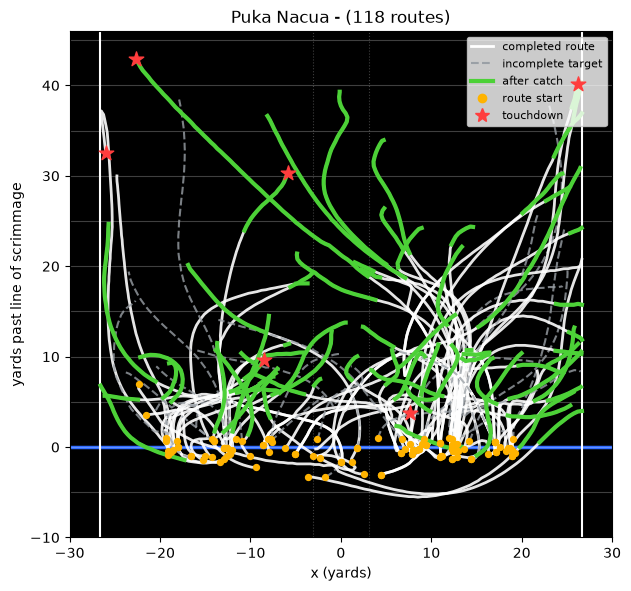

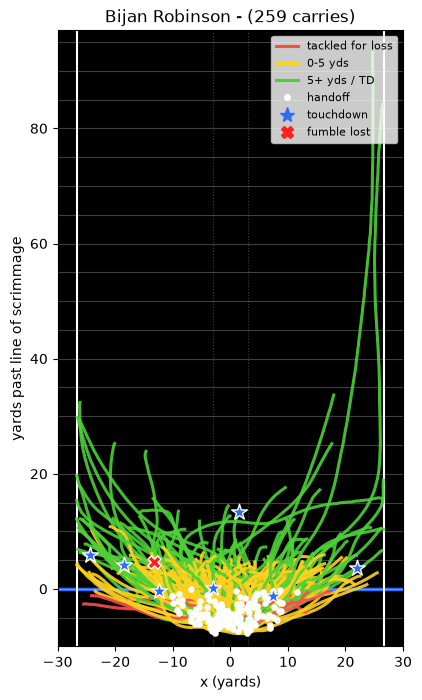

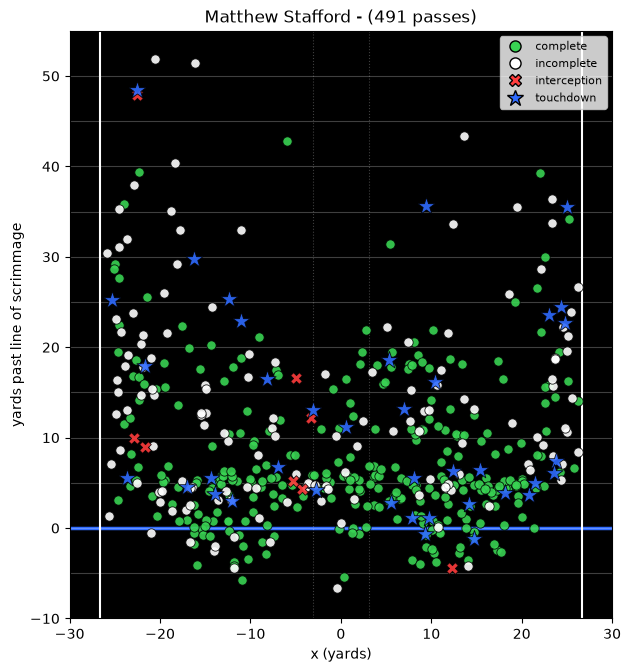

In [45]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def draw_field(ax, ymin=-10, ymax=40):
    """Simple top-down field: sidelines, LOS, 5-yd lines, hash marks. x in yards, y = yards past LOS."""
    ymin, ymax = int(math.floor(ymin)), int(math.ceil(ymax))          # range() needs ints
    ax.set_facecolor('black')                                        # black field, so heatmap colors (inferno etc.) read cleanly
    for y in range(ymin - ymin % 5, ymax + 1, 5):
        ax.axhline(y, color='white', alpha=0.25, lw=0.8)
    ax.axhline(0, color='#2f6bff', lw=2.5, zorder=1)                 # line of scrimmage
    for x in (-26.67, 26.67):
        ax.axvline(x, color='white', lw=1.5)                          # sidelines
    for x in (-3.08, 3.08):
        ax.axvline(x, color='white', alpha=0.25, lw=0.8, ls=':')     # hashes
    ax.set_xlim(-30, 30)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal')
    ax.set_xlabel('x (yards)')
    ax.set_ylabel('yards past line of scrimmage')


def count(data, id_col):
    """Number of routes/carries in `data`. The ids restart at 1 every game, so count (game_id, id) pairs."""
    return data.groupby(['game_id', id_col]).ngroups


# ---------------------------------------------------------------- routes
ROUTE_STYLE = {'COMPLETE': dict(color='white', lw=2, alpha=0.9),
               'INCOMPLETE': dict(color='#9aa0a6', lw=1.5, alpha=0.8, ls='--')}

def plot_routes(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymax=max(30, data['y_coord'].max() + 3))
    for _, r in data.groupby(['game_id', 'route_id']):              # one line per route per game
        r = r.sort_values('point')
        ax.plot(r['x_coord'], r['y_coord'], **ROUTE_STYLE[r['route_type'].iloc[0]], zorder=3)
        ac = r[r['segment'] == 'after_catch']                        # yards after catch in green
        if len(ac):
            ax.plot(ac['x_coord'], ac['y_coord'], color='#4cd137', lw=3, zorder=4)
        ax.scatter(r['x_coord'].iloc[0], r['y_coord'].iloc[0], s=18, color='#ffb300', zorder=5)   # start
        if r['touchdown'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=120, marker='*', color='#ff3d3d', zorder=6)
    ax.set_title(title)
    return ax

route_legend = [Line2D([], [], color='white', lw=2, label='completed route'),
                Line2D([], [], color='#9aa0a6', lw=1.5, ls='--', label='incomplete target'),
                Line2D([], [], color='#4cd137', lw=3, label='after catch'),
                Line2D([], [], color='#ffb300', marker='o', ls='', label='route start'),
                Line2D([], [], color='#ff3d3d', marker='*', ls='', ms=10, label='touchdown')]


# ---------------------------------------------------------------- carries
CARRY_COLORS = {'LOSS': '#ff4d4d', 'SHORT': '#ffd21f', 'LONG': '#4cd137'}   # same colours as the NGS chart

def plot_carries(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymin=-10, ymax=max(20, data['y_coord'].max() + 3))
    for _, r in data.groupby(['game_id', 'carry_id']):              # one line per carry per game
        r = r.sort_values('point')
        ax.plot(r['x_coord'], r['y_coord'], color=CARRY_COLORS[r['gain_class'].iloc[0]], lw=2.2, alpha=0.9, zorder=3)
        ax.scatter(r['x_coord'].iloc[0], r['y_coord'].iloc[0], s=14, color='white', zorder=5)      # handoff
        if r['touchdown'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=140, marker='*', color='#2f6bff',
                       edgecolor='white', zorder=6)
        if r['fumble_lost'].iloc[0]:
            ax.scatter(r['x_coord'].iloc[-1], r['y_coord'].iloc[-1], s=90, marker='X', color='#ff1f1f',
                       edgecolor='white', zorder=6)
    ax.set_title(title)
    return ax

carry_legend = [Line2D([], [], color=CARRY_COLORS['LOSS'], lw=2.2, label='tackled for loss'),
                Line2D([], [], color=CARRY_COLORS['SHORT'], lw=2.2, label='0-5 yds'),
                Line2D([], [], color=CARRY_COLORS['LONG'], lw=2.2, label='5+ yds / TD'),
                Line2D([], [], color='white', marker='o', ls='', ms=4, label='handoff'),
                Line2D([], [], color='#2f6bff', marker='*', ls='', ms=11, label='touchdown'),
                Line2D([], [], color='#ff1f1f', marker='X', ls='', ms=8, label='fumble lost')]

# ---------------------------------------------------------------- passes
# Colours follow the NGS pass chart. NOTE: the chart doesn't draw every incompletion (throwaways, spikes...),
# so a QB can have fewer INCOMPLETE dots than (attempts - completions - interceptions).
PASS_STYLE = {'COMPLETE':     dict(color='#39d353', marker='o', s=45, label='complete'),
              'INCOMPLETE':   dict(color='white',   marker='o', s=45, label='incomplete'),
              'INTERCEPTION': dict(color='#ff3d3d', marker='X', s=70, label='interception'),
              'TOUCHDOWN':    dict(color='#2f6bff', marker='*', s=170, label='touchdown')}

def plot_passes(data, title, ax=None):
    ax = ax or plt.subplots(figsize=(7, 8))[1]
    draw_field(ax, ymin=-10, ymax=max(35, data['y_coord'].max() + 3))
    for ptype, style in PASS_STYLE.items():                            # draw TD / INT last so they sit on top
        d = data[data['pass_type'] == ptype]
        ax.scatter(d['x_coord'], d['y_coord'], edgecolor='black', linewidth=0.6, alpha=0.9,
                   zorder=4 if ptype in ('COMPLETE', 'INCOMPLETE') else 6,
                   **{k: v for k, v in style.items() if k != 'label'})
    ax.set_title(title)
    return ax

pass_legend = [Line2D([], [], color=s['color'], marker=s['marker'], ls='', ms=8 if k != 'TOUCHDOWN' else 12,
                      markeredgecolor='black', label=s['label']) for k, s in PASS_STYLE.items()]


# --- every route target ---
ax = plot_routes(routes, f'{routes["name"].iloc[0]} - ({count(routes, "route_id")} routes)')
ax.legend(handles=route_legend, loc='upper right', fontsize=8)
plt.show()

# --- every carry ---
ax = plot_carries(carries, f'{carries["name"].iloc[0]} - ({count(carries, "carry_id")} carries)')
ax.legend(handles=carry_legend, loc='upper right', fontsize=8)
plt.show()

# --- every pass (passes is already one row per pass, so just len(), not the route/carry count() helper) ---
ax = plot_passes(passes, f'{passes["name"].iloc[0]} - ({len(passes)} passes)')
ax.legend(handles=pass_legend, loc='upper right', fontsize=8)
plt.show()